In [1]:
# imports
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, r2_score
import math

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")
print("done")

done


## Data loading and preprocessing
### Load and display data
Specifying target column for easier use down the line

Can change said column later if wanted

In [2]:
# load data
target_value = "Anomaly Scores"
data = pd.read_csv("cybersecurity_attacks.csv")
data.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


### Missing values
The data does contain missing values

Using mean imputation to fill values, could use something like knn or drop rows/columns instead if wanted

Dropping target column here as well

In [3]:
data.columns[data.isnull().sum() != 0]

Index(['Malware Indicators', 'Alerts/Warnings', 'Proxy Information',
       'Firewall Logs', 'IDS/IPS Alerts'],
      dtype='object')

In [4]:
num_null_counts = data.isnull().sum()
null_cols = data.columns[num_null_counts != 0]
if len(null_cols) > 0:
    print("Data contains NaN values")
    display(num_null_counts[num_null_counts != 0])

else:
    print("Data does not contain NaN values")


Data contains NaN values


Malware Indicators    20000
Alerts/Warnings       20067
Proxy Information     19851
Firewall Logs         19961
IDS/IPS Alerts        20050
dtype: int64

In [5]:

for col in null_cols:
    print(f"{col}: {data[col].nunique()} {data[col].unique()}")


Malware Indicators: 1 ['IoC Detected' nan]
Alerts/Warnings: 1 [nan 'Alert Triggered']
Proxy Information: 20148 ['150.9.97.135' nan '114.133.48.179' ... '60.51.30.46' '137.76.130.8'
 '112.169.115.139']
Firewall Logs: 1 ['Log Data' nan]
IDS/IPS Alerts: 1 [nan 'Alert Data']


In [6]:
data.groupby("Proxy Information")["Proxy Information"].count().sort_values(ascending=False)

Proxy Information
39.123.165.122    2
32.128.50.214     1
32.127.63.16      1
32.127.49.63      1
32.127.160.76     1
                 ..
166.56.182.249    1
166.49.59.72      1
166.48.160.244    1
166.44.193.97     1
166.72.179.119    1
Name: Proxy Information, Length: 20148, dtype: int64

can remove the colum proxy info because they're all unique values, could potentially split all the ip address segments into their own groups but I do not have enough domain knowledge to know if that would be useful

In [7]:
data = data.drop(null_cols, axis=1)
data.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Anomaly Scores,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,28.67,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,51.50,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,87.42,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,15.79,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,0.52,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",Firewall


In [8]:
for col in data.columns:
    display(data.groupby(col)[col].count().sort_values(ascending=False))

Timestamp
2022-04-17 20:05:34    2
2022-06-06 12:12:43    2
2022-06-11 14:28:15    2
2022-07-07 16:09:18    1
2022-07-07 16:39:17    1
                      ..
2021-04-09 02:04:23    1
2021-04-09 06:47:50    1
2021-04-09 07:10:44    1
2021-04-09 07:24:18    1
2021-04-08 17:33:13    1
Name: Timestamp, Length: 39997, dtype: int64

Source IP Address
99.50.246.63     1
99.54.94.213     1
99.6.24.231      1
99.60.173.124    1
99.60.219.73     1
                ..
1.10.74.49       1
1.100.115.5      1
1.101.138.199    1
1.103.126.230    1
1.103.203.179    1
Name: Source IP Address, Length: 40000, dtype: int64

Destination IP Address
99.51.95.207     1
99.53.242.226    1
99.54.125.108    1
99.54.142.207    1
99.58.215.130    1
                ..
1.101.117.52     1
1.101.24.101     1
1.102.176.87     1
1.103.183.132    1
1.105.159.177    1
Name: Destination IP Address, Length: 40000, dtype: int64

Source Port
41341    6
47259    5
53397    5
15669    5
24528    5
        ..
65393    1
65396    1
65401    1
65405    1
65406    1
Name: Source Port, Length: 29761, dtype: int64

Destination Port
7508     6
34117    6
25350    5
35081    5
15150    5
        ..
25863    1
25859    1
25858    1
25856    1
25906    1
Name: Destination Port, Length: 29895, dtype: int64

...

User Information
Heer Lad            6
Ishaan Chaudhari    6
Vritika Dara        5
Elakshi Koshy       5
Urvi Mani           5
                   ..
Ivan Mane           1
Ivan Mallick        1
Ivan Maharaj        1
Ivan Magar          1
Ivan Ratti          1
Name: User Information, Length: 32389, dtype: int64

Device Information
Mozilla/5.0 (compatible; MSIE 6.0; Windows NT 6.2; Trident/3.0)                                      35
Mozilla/5.0 (compatible; MSIE 5.0; Windows 98; Trident/4.1)                                          34
Mozilla/5.0 (compatible; MSIE 6.0; Windows CE; Trident/4.0)                                          33
Mozilla/5.0 (compatible; MSIE 7.0; Windows NT 6.0; Trident/3.0)                                      31
Mozilla/5.0 (compatible; MSIE 5.0; Windows NT 5.2; Trident/4.1)                                      31
                                                                                                     ..
Mozilla/5.0 (Windows NT 5.1) AppleWebKit/531.1 (KHTML, like Gecko) Chrome/28.0.801.0 Safari/531.1     1
Mozilla/5.0 (Windows NT 5.1) AppleWebKit/531.1 (KHTML, like Gecko) Chrome/24.0.829.0 Safari/531.1     1
Mozilla/5.0 (Windows NT 5.1) AppleWebKit/531.1 (KHTML, like Gecko) Chrome/13.0.823.0 Safari/531.1     1
Mozilla/5.0 (Windows NT 5.1) AppleWebKit/531.

Network Segment
Segment C    13408
Segment B    13319
Segment A    13273
Name: Network Segment, dtype: int64

Geo-location Data
Ghaziabad, Meghalaya          16
Kalyan-Dombivli, Jharkhand    15
Ghaziabad, Uttarakhand        14
Ghaziabad, Tripura            14
Kottayam, Nagaland            13
                              ..
Visakhapatnam, Assam           1
Visakhapatnam, Bihar           1
Adoni, Meghalaya               1
Yamunanagar, Odisha            1
Yamunanagar, Uttarakhand       1
Name: Geo-location Data, Length: 8723, dtype: int64

Log Source
Firewall    20116
Server      19884
Name: Log Source, dtype: int64

remove cols that have mostly unique values

NOTE: you could likely split all of these columns into their own columns (127.0.0.1) -> (127), (0), (0), (1) etc.

In [9]:
rm_cols = ["Timestamp", "Source IP Address", "Destination IP Address", "Payload Data"]
data = data.drop(rm_cols, axis=1)
data.head()

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Anomaly Scores,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Log Source
0,31225,17616,ICMP,503,Data,HTTP,28.67,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",Server
1,17245,48166,ICMP,1174,Data,HTTP,51.50,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",Firewall
2,16811,53600,UDP,306,Control,HTTP,87.42,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",Firewall
3,20018,32534,UDP,385,Data,HTTP,15.79,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",Firewall
4,6131,26646,TCP,1462,Data,DNS,0.52,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",Firewall


In [10]:
y_vals = data[target_value]
data = data.drop(target_value, axis=1)
data.head()

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Log Source
0,31225,17616,ICMP,503,Data,HTTP,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",Server
1,17245,48166,ICMP,1174,Data,HTTP,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",Firewall
2,16811,53600,UDP,306,Control,HTTP,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",Firewall
3,20018,32534,UDP,385,Data,HTTP,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",Firewall
4,6131,26646,TCP,1462,Data,DNS,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",Firewall


## scale, pca, and splitting data

### encode categorical data

In [11]:
# encode categorical data
encode_cols = ["Protocol", "Packet Type", "Traffic Type", "Attack Type", "Attack Signature", "Action Taken", "Severity Level", "User Information", "Device Information", "Network Segment", "Geo-location Data", "Log Source"]
for col in encode_cols:
    data[col] = data[col].astype('category')
    data[col] = data[col].cat.codes
    data[col] = data[col].astype('int64')
data.head()

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Log Source
0,31225,17616,0,503,1,2,2,1,2,1,22830,18202,0,3723,1
1,17245,48166,0,1174,1,2,2,0,0,1,27434,18188,1,1677,0
2,16811,53600,2,306,0,2,0,1,1,1,10139,18280,2,1707,0
3,20018,32534,2,385,1,2,2,1,0,2,9216,4793,1,3750,0
4,6131,26646,1,1462,1,0,0,1,0,1,6462,17964,2,577,0


### Scale data

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)
X_scaled

array([[-0.09403762, -0.83635746, -1.21937263, ..., -1.22855875,
        -0.24612521,  1.00581692],
       [-0.84726252,  0.80837614, -1.21937263, ..., -0.00413244,
        -1.05726911, -0.99421672],
       [-0.8706459 ,  1.10092875,  1.22732439, ...,  1.22029387,
        -1.0453755 , -0.99421672],
       ...,
       [-0.56386031, -0.43063856,  1.22732439, ...,  1.22029387,
         0.22922255,  1.00581692],
       [-0.69812615, -1.63923511,  1.22732439, ..., -0.00413244,
         1.03640191,  1.00581692],
       [ 0.92491727,  1.20725768, -1.21937263, ..., -1.22855875,
         0.84967231, -0.99421672]])

## Applying PCA

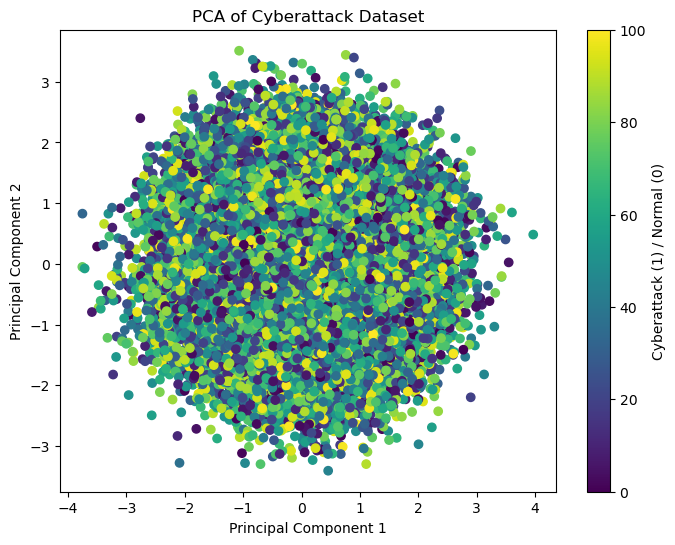

In [13]:
#apply PCA to reduce to 2 components
pca=PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
#visualize components of PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_vals, cmap='viridis', marker='o')
plt.title('PCA of Cyberattack Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cyberattack (1) / Normal (0)')
plt.show()

### Split data with 80/20 split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, 
    y_vals, 
    test_size=0.2, 
    random_state=42)